In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

from pathlib import Path

def _abs_parquet(rel):
    """Resolve a path relative to src/notebooks and return the absolute parquet path."""
    here = Path.cwd().resolve()
    data = None
    for candidate in (here, *here.parents):
        if (candidate / 'src' / 'data').is_dir() and (candidate / 'src' / 'notebooks').is_dir():
            data = candidate / 'src' / 'data'
            break
        if candidate.name == 'notebooks' and (candidate.parent / 'data').is_dir():
            data = (candidate.parent / 'data').resolve()
            break
    if data is None:
        raise FileNotFoundError(f'Could not locate src/data from {here}')
    path = (data / rel.removeprefix('../data/')).resolve()
    matches = list(path.parent.glob(path.name)) if '*' in path.name else ([path] if path.is_file() else [])
    if not matches:
        raise FileNotFoundError(path)
    return str(path)

repos_path = _abs_parquet('../data/gitskills_data/data/repos/*.parquet')
artifacts_path = _abs_parquet('../data/gitskills_data/data/artifacts/*.parquet')
artifact_siblings_path = _abs_parquet('../data/gitskills_data/data/artifact_siblings/*.parquet')
mining_runs_path = _abs_parquet('../data/gitskills_data/data/mining_runs/*.parquet')
skill_features_path = _abs_parquet('../data/generated_data/skill_features.parquet')
file_agents_path = _abs_parquet('../data/generated_data/file_agents.parquet')

con = duckdb.connect(database=':memory:')

## Near-duplicates the hash misses

Exact `file_sha` dedup treats only byte-identical files as copies. This notebook measures two looser matches on representative skills (`dedup_primary = 1`): bodies that become identical after dropping front matter and collapsing whitespace, and bodies that are near each other in a TF-IDF space.


#### Whitespace and formatting

Re-hash a normalized body (leading front-matter block removed, lowercased, whitespace collapsed) and count how many extra contents merge.


In [2]:
norm_groups = con.execute(f"""
WITH reps AS (
  SELECT file_sha,
         sha256(trim(regexp_replace(
           lower(regexp_replace(coalesce(content, ''), '^---.*?---', '', 's')),
           '\\s+', ' ', 'g'))) AS norm_hash
  FROM read_parquet('{artifacts_path}')
  WHERE dedup_primary = 1
), sized AS (
  SELECT norm_hash, COUNT(*) AS n FROM reps GROUP BY 1
)
SELECT (SELECT COUNT(*) FROM reps) AS file_sha_groups,
       COUNT(*) AS norm_hash_groups,
       (SELECT COUNT(*) FROM reps) - COUNT(*) AS extra_merges,
       COUNT(*) FILTER (WHERE n > 1) AS groups_with_2plus,
       SUM(n) FILTER (WHERE n > 1) AS contents_in_merged_groups
FROM sized
""").df()
norm_groups.T.rename(columns={0: "value"})


,value
file_sha_groups,1877981.0
norm_hash_groups,1679607.0
extra_merges,198374.0
groups_with_2plus,98115.0
contents_in_merged_groups,296489.0


Normalization merges 198,374 contents that `file_sha` kept apart: 1,877,981 hashes become 1,679,607 normalized hashes. 98,115 of those hashes cover two or more distinct file hashes (296,489 contents). Formatting-only copies are real, and they are a minority of distinct contents (10.6% collapse into another content).


#### TF-IDF nearest neighbour

For every skill in the sample, the most similar *different* content. The matrix is built on a deterministic 20,000-skill sample (`body_chars >= 200`, ordered by `hash(file_sha)`), because a nearest-neighbour matrix over all 1.8 million readable skills does not fit in memory. A sampled skill's true nearest twin is often outside the sample, so these shares are a floor.


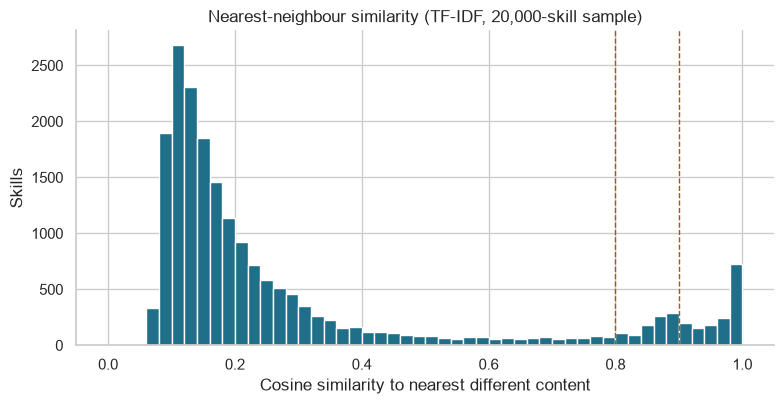

,threshold,skills,%
0,0.95,1053,5.3
1,0.90,1499,7.5
2,0.80,2426,12.1
3,0.70,2769,13.8
4,0.60,3090,15.4


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

base = con.execute(f"""
WITH ids AS (
  SELECT file_sha
  FROM read_parquet('{artifacts_path}')
  WHERE dedup_primary = 1 AND body_chars >= 200
  ORDER BY hash(file_sha), file_sha
  LIMIT 20000
)
SELECT a.file_sha, a.repo_full_name, a.name, a.body_chars, a.content, r.owner
FROM ids
JOIN read_parquet('{artifacts_path}') a ON a.file_sha = ids.file_sha AND a.dedup_primary = 1
LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
""").df()

def normalize(text):
    text = re.sub(r"^---.*?---", "", text or "", count=1, flags=re.S)
    return re.sub(r"\s+", " ", text.lower()).strip()

base["norm"] = base.content.map(normalize)
X = TfidfVectorizer(min_df=2, max_df=.5, ngram_range=(1, 2), max_features=200_000,
                    sublinear_tf=True).fit_transform(base.norm.str.slice(0, 5000))
dist_, idx_ = NearestNeighbors(n_neighbors=2, metric="cosine").fit(X).kneighbors(X)
base["nn_sim"] = 1 - dist_[:, 1]
base["nn_idx"] = idx_[:, 1]

fig, ax = plt.subplots()
ax.hist(base.nn_sim, bins=50, color=ACCENT)
for t in (.8, .9):
    ax.axvline(t, color="#9A5B12", ls="--", lw=1)
ax.set_xlabel("Cosine similarity to nearest different content")
ax.set_ylabel("Skills")
ax.set_title("Nearest-neighbour similarity (TF-IDF, 20,000-skill sample)")
plt.tight_layout(); plt.show()
nn_thresholds = pd.DataFrame({
    "threshold": [.95, .9, .8, .7, .6],
    "skills": [(base.nn_sim >= t).sum() for t in (.95, .9, .8, .7, .6)],
    "%": [round(100 * (base.nn_sim >= t).mean(), 1) for t in (.95, .9, .8, .7, .6)],
})
nn_thresholds


In [4]:
pairs = base[(base.nn_sim >= .7) & (base.nn_sim < .95)].copy()
pairs["twin_name"] = base.name.iloc[pairs.nn_idx].values
pairs["twin_repo"] = base.repo_full_name.iloc[pairs.nn_idx].values
pairs["twin_owner"] = base.owner.iloc[pairs.nn_idx].values
diff_name = pairs[pairs.name.fillna("").str.lower() != pairs.twin_name.fillna("").str.lower()]
print(f"{len(diff_name):,} of {len(pairs):,} near-duplicate skills have a differently named twin")
diff_name.sort_values("nn_sim", ascending=False)[
    ["nn_sim", "name", "twin_name", "repo_full_name", "twin_repo"]
].head(15).round(2)


780 of 1,716 near-duplicate skills have a differently named twin


,nn_sim,name,twin_name,repo_full_name,twin_repo
3006,0.95,Python Package Build System,pdf-slack,qyb156/PoisonedSkills,qyb156/PoisonedSkills
2563,0.95,customer-feedback,user-story-map,GeorgeQLe/agentic-skills,GeorgeQLe/agentic-skills
10311,0.95,product-expert-209,product-expert-244,Sandeeprdy1729/skill_galaxy,Sandeeprdy1729/skill_galaxy
10307,0.95,product-expert-244,product-expert-209,Sandeeprdy1729/skill_galaxy,Sandeeprdy1729/skill_galaxy
10303,0.95,creative-expert-159,creative-expert-225,Sandeeprdy1729/skill_galaxy,Sandeeprdy1729/skill_galaxy
10304,0.95,creative-expert-225,creative-expert-159,Sandeeprdy1729/skill_galaxy,Sandeeprdy1729/skill_galaxy
16966,0.95,onepagecrm,jazzhr,membranedev/application-skills,membranedev/application-skills
10070,0.95,aid-prototype,aid-document,AndreVianna/aid-methodology,AndreVianna/aid-methodology
10077,0.95,aid-document,aid-prototype,AndreVianna/aid-methodology,AndreVianna/aid-methodology
9467,0.95,owasp-docker-security,owasp-www-project-belva,firebitsbr/OWASP-claudeskills,firebitsbr/OWASP-claudeskills


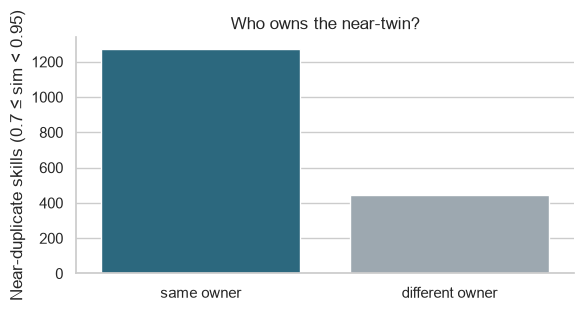

,skills
same owner,1274
different owner,442


In [5]:
split = (pairs.owner == pairs.twin_owner).map({True: "same owner", False: "different owner"}).value_counts()
fig, ax = plt.subplots(figsize=(6, 3.2))
sns.barplot(x=split.index, y=split.values, hue=split.index,
            palette=[ACCENT, GREY][:len(split)], legend=False, ax=ax)
ax.set_ylabel("Near-duplicate skills (0.7 ≤ sim < 0.95)")
ax.set_xlabel("")
ax.set_title("Who owns the near-twin?")
plt.tight_layout(); plt.show()
split.to_frame("skills")


In the 20,000-skill sample, 12.1% have a nearest neighbour at cosine similarity 0.8 or higher. Among pairs in the band 0.7 ≤ similarity < 0.95, 780 of 1,716 (45.5%) use a different front-matter name, so a name match would miss them. 1,274 of those pairs belong to the same owner and 442 to different owners: most near-twins are template series one account republished, and a smaller set is cross-project adaptation.

These rates are a floor. The sample holds about 1.1% of distinct contents, and a skill's closest twin may not have been drawn.
The next section joins near-copies to AI trailers and bot authors. Formatting-hash groups cover every representative. The TF-IDF comparison stays on this sample, because a nearest-neighbour matrix of all readable skills does not fit in memory.


#### Summary


In [6]:
summary = pd.Series({
    "file_sha groups": int(norm_groups.file_sha_groups.iloc[0]),
    "normalized hash groups": int(norm_groups.norm_hash_groups.iloc[0]),
    "extra merges after whitespace normalization": int(norm_groups.extra_merges.iloc[0]),
    "sample size (readable skills)": int(len(base)),
    "sample skills with a near-twin at cosine >= 0.8": f"{(base.nn_sim >= .8).mean():.1%}",
    "near-dup pairs with a different name": int(len(diff_name)),
    "near-dup pairs with the same owner": int((pairs.owner == pairs.twin_owner).sum()),
})
summary.to_frame("value")


,value
file_sha groups,1877981
normalized hash groups,1679607
extra merges after whitespace normalization,198374
sample size (readable skills),20000
sample skills with a near-twin at cosine >= 0.8,12.1%
near-dup pairs with a different name,780
near-dup pairs with the same owner,1274


**Takeaways**
- Exact-hash dedup is reliable for byte-identical files, and it misses copies that differ only by case or whitespace.
- A meaningful share of sampled skills have a near-twin the hash does not merge. Many of those twins are renamed, and most share an owner.
- Names are a poor identity key in both directions: one name covers many texts, and near-duplicate texts often use different names.
- Near-copies are not an AI-trailer or coding-agent signature. On the full population, formatting-only twins carry an AI trailer less often than unique texts. In this sample, trailer skills are the least likely to have a near-twin.


## Near-copies, trailers, and bots

A nearest-neighbour matrix over all readable skills does not fit in memory, so the TF-IDF comparison stays on the 20,000-skill sample above. Two joins are still possible. The formatting hash from the first section covers every representative, and this section attaches each representative's first-commit AI trailer and bot class. The sample join asks whether a skill that already has a near-twin inside the sample is the one with a trailer or a bot author.


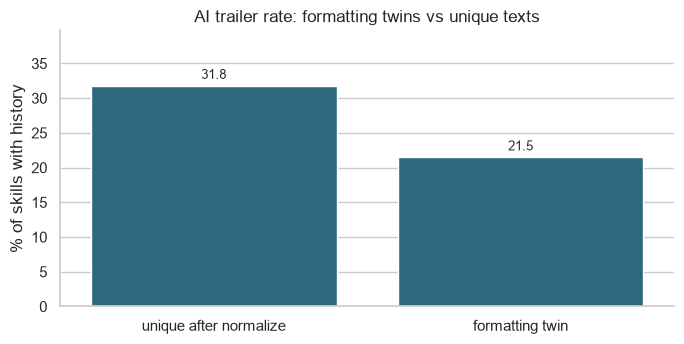

,kind,skills,pct_history,pct_ai_given_history,coding_agent_skills,pct_coding_agent_given_history,pct_any_bot_given_history
0,unique after normalize,1581492,24.7,31.8,853.0,0.2,1.0
1,formatting twin,296489,23.0,21.5,75.0,0.1,1.3


In [7]:
AGENTS  = r"copilot|devin|jules|opencode|^claude|lovable|kilo-code|codex|factory-droid|amazon-q|codegen|capy-ai|warp-dev|cursor"
DISTRIB = r"clawdhub|txtskills|skill"

def _trailer(column):
    needles = ("claude", "anthropic", "cursor", "copilot", "codex", "openai", "gemini")
    return " OR ".join(
        f"lower(coalesce({column}, '')) LIKE '%co-authored-by:%{name}%'" for name in needles
    )

norm_by_signal = con.execute(f"""
WITH reps AS (
  SELECT history_fetched = 1 AS has_history,
         ({_trailer('first_commit_message')}) AS ai_first,
         CASE
           WHEN coalesce(first_commit_author_type, '') NOT IN ('Bot', 'ProgrammaticAccessBot')
             THEN 'not a bot'
           WHEN lower(coalesce(first_commit_author, '')) IN ('github-actions[bot]', 'dependabot[bot]', 'renovate[bot]')
             OR lower(coalesce(first_commit_author, '')) LIKE '%release%'
             OR lower(coalesce(first_commit_author, '')) LIKE '%sync%'
             THEN 'CI, release and sync'
           WHEN regexp_matches(lower(coalesce(first_commit_author, '')), '{AGENTS}')
             THEN 'Coding agents'
           WHEN regexp_matches(lower(coalesce(first_commit_author, '')), '{DISTRIB}')
             THEN 'Skill distribution'
           ELSE 'Other project bots'
         END AS bot_group,
         sha256(trim(regexp_replace(
           lower(regexp_replace(coalesce(content, ''), '^---.*?---', '', 's')),
           '\\s+', ' ', 'g'))) AS norm_hash
  FROM read_parquet('{artifacts_path}')
  WHERE dedup_primary = 1
),
sized AS (SELECT norm_hash, COUNT(*) AS n FROM reps GROUP BY 1)
SELECT CASE WHEN s.n > 1 THEN 'formatting twin' ELSE 'unique after normalize' END AS kind,
       COUNT(*) AS skills,
       ROUND(100.0 * AVG(r.has_history::INT), 1) AS pct_history,
       ROUND(100.0 * AVG(CASE WHEN r.has_history THEN r.ai_first::INT END), 1) AS pct_ai_given_history,
       SUM(CASE WHEN r.has_history AND r.bot_group = 'Coding agents' THEN 1 ELSE 0 END) AS coding_agent_skills,
       ROUND(100.0 * AVG(CASE WHEN r.has_history AND r.bot_group = 'Coding agents' THEN 1
                              WHEN r.has_history THEN 0 END), 1) AS pct_coding_agent_given_history,
       ROUND(100.0 * AVG(CASE WHEN r.has_history AND r.bot_group <> 'not a bot' THEN 1
                              WHEN r.has_history THEN 0 END), 1) AS pct_any_bot_given_history
FROM reps r
JOIN sized s USING (norm_hash)
GROUP BY 1
ORDER BY skills DESC
""").df()

fig, ax = plt.subplots(figsize=(7, 3.6))
sns.barplot(data=norm_by_signal, x="kind", y="pct_ai_given_history", color=ACCENT, ax=ax)
ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=9)
ax.set_ylim(0, norm_by_signal.pct_ai_given_history.max() * 1.25)
ax.set_xlabel("")
ax.set_ylabel("% of skills with history")
ax.set_title("AI trailer rate: formatting twins vs unique texts")
plt.tight_layout(); plt.show()
norm_by_signal


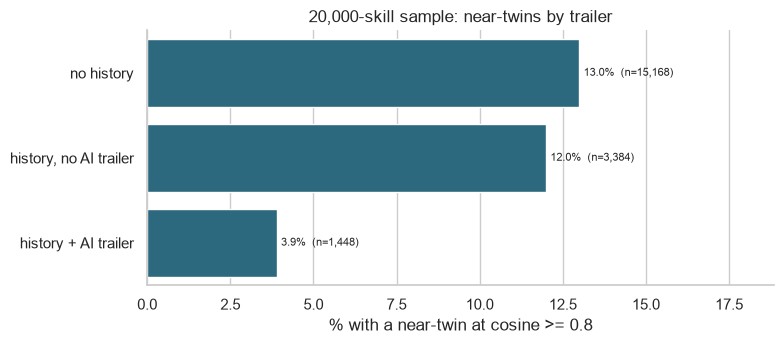

(                    group  skills  near  pct_near
 0              no history   15168  1965      13.0
 1  history, no AI trailer    3384   405      12.0
 2    history + AI trailer    1448    56       3.9,
    both_history_near_pairs  same_trailer  both_have_trailer
 0                      133           110                 11,
               bot_group  skills  near  pct_near
 3            no history   15168  1965      13.0
 4             not a bot    4783   457       9.6
 0  CI, release and sync      37     4      10.8
 1         Coding agents      10     0       0.0
 2    Other project bots       2     0       0.0)

In [8]:
sample_signals = con.execute(f"""
SELECT a.file_sha,
       a.history_fetched = 1 AS has_history,
       ({_trailer('a.first_commit_message')}) AS ai_first,
       CASE
         WHEN NOT (a.history_fetched = 1) THEN 'no history'
         WHEN coalesce(a.first_commit_author_type, '') NOT IN ('Bot', 'ProgrammaticAccessBot')
           THEN 'not a bot'
         WHEN lower(coalesce(a.first_commit_author, '')) IN ('github-actions[bot]', 'dependabot[bot]', 'renovate[bot]')
           OR lower(coalesce(a.first_commit_author, '')) LIKE '%release%'
           OR lower(coalesce(a.first_commit_author, '')) LIKE '%sync%'
           THEN 'CI, release and sync'
         WHEN regexp_matches(lower(coalesce(a.first_commit_author, '')), '{AGENTS}')
           THEN 'Coding agents'
         WHEN regexp_matches(lower(coalesce(a.first_commit_author, '')), '{DISTRIB}')
           THEN 'Skill distribution'
         ELSE 'Other project bots'
       END AS bot_group
FROM read_parquet('{artifacts_path}') a
WHERE a.dedup_primary = 1
  AND a.file_sha IN (SELECT UNNEST(?))
""", [base.file_sha.tolist()]).df().set_index("file_sha")

base["has_history"] = base.file_sha.map(sample_signals.has_history)
base["ai_first"] = base.file_sha.map(sample_signals.ai_first).astype(bool)
base["bot_group"] = base.file_sha.map(sample_signals.bot_group)
base["near"] = base.nn_sim >= 0.8

def _near_row(mask, group):
    sub = base[mask]
    return {"group": group, "skills": int(len(sub)),
            "near": int(sub.near.sum()),
            "pct_near": round(100 * sub.near.mean(), 1) if len(sub) else None}

near_by_signal = pd.DataFrame([
    _near_row(~base.has_history, "no history"),
    _near_row(base.has_history & ~base.ai_first, "history, no AI trailer"),
    _near_row(base.has_history & base.ai_first, "history + AI trailer"),
])
order = list(near_by_signal.group)
fig, ax = plt.subplots(figsize=(8, 3.6))
sns.barplot(data=near_by_signal, y="group", x="pct_near", color=ACCENT, order=order, ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{p:.1f}%  (n={n:,})" for p, n in zip(near_by_signal.pct_near, near_by_signal.skills)],
             padding=3, fontsize=8)
ax.set_xlim(0, near_by_signal.pct_near.max() * 1.45)
ax.set_xlabel("% with a near-twin at cosine >= 0.8")
ax.set_ylabel("")
ax.set_title("20,000-skill sample: near-twins by trailer")
plt.tight_layout(); plt.show()

near = base[base.near]
twin_ai = base.ai_first.to_numpy()[near.nn_idx]
twin_hist = base.has_history.to_numpy()[near.nn_idx]
both = near[near.has_history.to_numpy() & twin_hist]
agree = pd.DataFrame({
    "both_history_near_pairs": [int(len(both))],
    "same_trailer": [int((both.ai_first.to_numpy() == twin_ai[near.has_history.to_numpy() & twin_hist]).sum())],
    "both_have_trailer": [int((both.ai_first.to_numpy() & twin_ai[near.has_history.to_numpy() & twin_hist]).sum())],
})
bot_near = (base.groupby("bot_group", as_index=False)
              .agg(skills=("file_sha", "size"), near=("near", "sum")))
bot_near["pct_near"] = (100 * bot_near.near / bot_near.skills).round(1)
near_by_signal, agree, bot_near.sort_values("skills", ascending=False)


#### Findings

**Formatting-only copies are not an AI-trailer population.** On every representative, 296,489 contents share a normalized body with at least one other content, and 1,581,492 stay unique. History coverage is similar (23.0% versus 24.7%). Among skills with history, the AI-trailer rate is lower for formatting twins (21.5%) than for unique texts (31.8%). Coding-agent bots are rare on both sides: 75 formatting twins and 853 unique texts, 0.1% and 0.2% of those with history. Any bot author is 1.3% versus 1.0%. A whitespace-only copy is not evidence that an agent or a bot wrote the skill.

**Inside the 20,000-skill sample, trailer skills are the least likely to have a near-twin.** 13.0% of skills with no history have a neighbour at cosine 0.8 or higher (1,968 of 15,168), and 12.0% of skills with history but no AI trailer do (406 of 3,384). Skills whose first commit names an AI tool do so only 3.9% of the time (56 of 1,448). This comparison is a floor: a trailer's real twin may not have been drawn. It runs in the same direction as the full-population formatting hash, which is not a sample.

**A shared trailer does not travel with the near-twin.** Of the near skills whose own history and the twin's history were both fetched, 133 pairs, 109 (82.0%) agree on whether an AI trailer is present. 98 of those 133 agree because neither commit has a trailer. Only 11 pairs both have one. The sample holds 10 skills first committed by a coding agent, and none of them has a near-twin in the sample, so a bot rate cannot be estimated from these 20,000 skills. The full-population counts above are the bot comparison.
